# Image Captioning — CNN + LSTM (From Scratch)

**Architecture:** Pretrained ResNet50 (encoder) → LSTM (decoder)  
**Dataset:** Flickr8k — 8,000 images, 5 captions each  
**Metric:** BLEU-4 score

```
Image → ResNet50 → 2048-d vector → FC → embed_size
                                           ↓
                              LSTM (teacher forcing during train)
                                           ↓
                                    word predictions
```

In [ ]:
%pip install torch torchvision nltk pillow tqdm

---
## 1. Download Dataset

Download **Flickr8k** from Kaggle (requires Kaggle API key):  
```bash
kaggle datasets download -d adityajn105/flickr8k
unzip flickr8k.zip -d flickr8k
```

Expected structure after unzip:
```
flickr8k/
  Images/          ← 8,091 .jpg files
  captions.txt     ← image,caption columns
```

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu
from collections import Counter
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


---
## 2. Load & Explore Captions

In [4]:
IMAGES_DIR    = 'Images'
CAPTIONS_FILE = 'captions.txt'

df = pd.read_csv(CAPTIONS_FILE)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(6)

Shape: (40455, 2)
Columns: ['image', 'caption']


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


In [5]:
# Rename to standard column names regardless of original header
df.columns = ['image', 'caption']
df['caption'] = df['caption'].str.strip()

print(f'Total captions : {len(df):,}')
print(f'Unique images  : {df["image"].nunique():,}')
print(f'Captions/image : {len(df) / df["image"].nunique():.1f}')

# Caption length distribution
df['length'] = df['caption'].apply(lambda x: len(x.split()))
print(f'\nCaption length — mean: {df["length"].mean():.1f}, max: {df["length"].max()}')

# Show a sample image + its 5 captions
sample_img = df['image'].iloc[0]
print(f'\nSample captions for {sample_img}:')
for cap in df[df['image'] == sample_img]['caption'].values:
    print(' -', cap)

Total captions : 40,455
Unique images  : 8,091
Captions/image : 5.0

Caption length — mean: 11.8, max: 38

Sample captions for 1000268201_693b08cb0e.jpg:
 - A child in a pink dress is climbing up a set of stairs in an entry way .
 - A girl going into a wooden building .
 - A little girl climbing into a wooden playhouse .
 - A little girl climbing the stairs to her playhouse .
 - A little girl in a pink dress going into a wooden cabin .


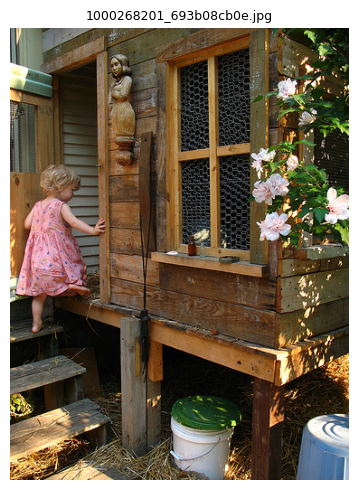

In [6]:
# Display the sample image
img = Image.open(os.path.join(IMAGES_DIR, sample_img))
plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f'{sample_img}', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Train / Val / Test Split

Split at the **image level** — all 5 captions for an image go to the same split.

In [7]:
all_images = df['image'].unique().tolist()
random.seed(42)
random.shuffle(all_images)

n = len(all_images)
train_imgs = set(all_images[:int(0.8 * n)])
val_imgs   = set(all_images[int(0.8 * n):int(0.9 * n)])
test_imgs  = set(all_images[int(0.9 * n):])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df['image'].isin(test_imgs)].reset_index(drop=True)

print(f'Train: {len(train_imgs)} images, {len(train_df)} captions')
print(f'Val  : {len(val_imgs)} images, {len(val_df)} captions')
print(f'Test : {len(test_imgs)} images, {len(test_df)} captions')

Train: 6472 images, 32360 captions
Val  : 809 images, 4045 captions
Test : 810 images, 4050 captions


---
## 4. Vocabulary

In [8]:
class Vocabulary:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    def build(self, captions):
        freq = Counter()
        idx = 4
        for cap in captions:
            for w in word_tokenize(cap.lower()):
                freq[w] += 1
                if freq[w] == self.freq_threshold:
                    self.stoi[w] = idx
                    self.itos[idx] = w
                    idx += 1

    def encode(self, text):
        return [self.stoi.get(w, self.UNK) for w in word_tokenize(text.lower())]

    def decode(self, indices):
        words = []
        for i in indices:
            if i == self.EOS:
                break
            if i not in (self.PAD, self.SOS):
                words.append(self.itos.get(i, '<UNK>'))
        return ' '.join(words)


vocab = Vocabulary(freq_threshold=5)
vocab.build(train_df['caption'].tolist())

print(f'Vocabulary size: {len(vocab):,} words')

Vocabulary size: 2,669 words


---
## 5. Dataset & DataLoader

In [9]:
class FlickrDataset(Dataset):
    def __init__(self, df, img_dir, vocab, transform):
        self.df        = df
        self.img_dir   = img_dir
        self.vocab     = vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img     = Image.open(os.path.join(self.img_dir, row['image'])).convert('RGB')
        img     = self.transform(img)
        tokens  = ([self.vocab.SOS]
                   + self.vocab.encode(row['caption'])
                   + [self.vocab.EOS])
        return img, torch.tensor(tokens, dtype=torch.long)


def collate_fn(batch, pad_idx):
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs)
    caps = nn.utils.rnn.pad_sequence(caps, batch_first=False, padding_value=pad_idx)
    return imgs, caps


from functools import partial

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

pad_idx     = vocab.PAD
collate     = partial(collate_fn, pad_idx=pad_idx)

train_dataset = FlickrDataset(train_df, IMAGES_DIR, vocab, transform_train)
val_dataset   = FlickrDataset(val_df,   IMAGES_DIR, vocab, transform_val)
test_dataset  = FlickrDataset(test_df,  IMAGES_DIR, vocab, transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

Train batches: 1012
Val   batches: 127


---
## 6. Model — CNN Encoder + LSTM Decoder

```
EncoderCNN:
  ResNet50 (frozen) → remove last FC → add new FC → embed_size

DecoderRNN:
  Embedding(vocab_size, embed_size)
  LSTM(embed_size, hidden_size, num_layers)
  Linear(hidden_size, vocab_size)
```

In [10]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        # Freeze all layers
        for p in resnet.parameters():
            p.requires_grad_(False)
        # Replace final classifier
        in_features = resnet.fc.in_features
        resnet.fc = nn.Sequential(
            nn.Linear(in_features, embed_size),
            nn.ReLU(),
            nn.Dropout(0.5),
        )
        # Unfreeze the new head
        for p in resnet.fc.parameters():
            p.requires_grad_(True)
        self.resnet = resnet

    def forward(self, x):
        return self.resnet(x)   # (B, embed_size)


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers, dropout=0.5):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm   = nn.LSTM(embed_size, hidden_size, num_layers,
                              batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc     = nn.Linear(hidden_size, vocab_size)
        self.drop   = nn.Dropout(dropout)

    def forward(self, features, captions):
        # features : (B, embed_size)
        # captions : (seq_len, B)  — drop last token (EOS) as input
        captions   = captions[:-1].T                      # (B, seq_len-1)
        embeddings = self.drop(self.embed(captions))      # (B, seq_len-1, embed)
        # Prepend image feature as first time-step
        inputs     = torch.cat([features.unsqueeze(1), embeddings], dim=1)  # (B, seq_len, embed)
        out, _     = self.lstm(inputs)
        return self.fc(out)   # (B, seq_len, vocab_size)

    def generate(self, feature, vocab, max_len=50):
        self.eval()
        tokens  = []
        x       = feature.unsqueeze(1)   # (1, 1, embed)
        # reshape for LSTM: (batch=1, seq=1, embed)
        x       = feature.unsqueeze(0).unsqueeze(0)  # wrong shape — fix below
        states  = None
        inp     = feature.unsqueeze(0)   # (1, embed) — first input is image
        inp     = inp.unsqueeze(1)       # (1, 1, embed)
        with torch.no_grad():
            for _ in range(max_len):
                out, states = self.lstm(inp, states)       # (1,1,hidden)
                logits      = self.fc(out.squeeze(1))      # (1, vocab)
                pred        = logits.argmax(1).item()
                tokens.append(pred)
                if pred == vocab.EOS:
                    break
                inp = self.drop(self.embed(torch.tensor([[pred]], device=feature.device)))
        return vocab.decode(tokens)


# Hyperparameters
EMBED_SIZE  = 256
HIDDEN_SIZE = 512
NUM_LAYERS  = 2
VOCAB_SIZE  = len(vocab)
LR          = 3e-4
NUM_EPOCHS  = 15

encoder = EncoderCNN(EMBED_SIZE).to(device)
decoder = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(device)

enc_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
dec_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'Encoder trainable params: {enc_params:,}')
print(f'Decoder trainable params: {dec_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Parth/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:08<00:00, 12.0MB/s]


Encoder trainable params: 524,544
Decoder trainable params: 5,730,669


---
## 7. Training

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.PAD)
optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)


def run_epoch(loader, train=True):
    encoder.train(train)
    decoder.train(train)
    total_loss = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, caps in tqdm(loader, desc='train' if train else 'val', leave=False):
            imgs = imgs.to(device)   # (B, 3, 224, 224)
            caps = caps.to(device)   # (seq_len, B)

            features = encoder(imgs)           # (B, embed)
            logits   = decoder(features, caps) # (B, seq_len, vocab)

            # Target: caps[1:] shifted — what word comes next
            targets = caps[1:].T.contiguous().view(-1)  # (B*(seq_len-1),)
            logits  = logits.view(-1, VOCAB_SIZE)        # (B*(seq_len-1), vocab)

            loss = criterion(logits, targets)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 5.0)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)
    scheduler.step(val_loss)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({'encoder': encoder.state_dict(), 'decoder': decoder.state_dict()}, 'best_cnn_lstm.pt')
        print('  → checkpoint saved')

train:   0%|          | 0/1012 [00:00<?, ?it/s]

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

---
## 8. BLEU Score Evaluation

In [ ]:
# Load best checkpoint
ckpt = torch.load('best_cnn_lstm.pt', map_location=device)
encoder.load_state_dict(ckpt['encoder'])
decoder.load_state_dict(ckpt['decoder'])
encoder.eval()
decoder.eval()

# Group all reference captions per image for BLEU
refs_by_img  = test_df.groupby('image')['caption'].apply(list).to_dict()
test_images  = test_df['image'].unique().tolist()

references  = []   # list of list of reference token lists
hypotheses  = []   # list of hypothesis token lists

with torch.no_grad():
    for img_name in tqdm(test_images, desc='Evaluating'):
        img_path = os.path.join(IMAGES_DIR, img_name)
        img      = transform_val(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
        feature  = encoder(img).squeeze(0)          # (embed_size,)
        caption  = decoder.generate(feature, vocab)

        hypotheses.append(caption.split())
        refs = [word_tokenize(r.lower()) for r in refs_by_img[img_name]]
        references.append(refs)

bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
print(f'BLEU-1: {bleu1:.4f}')
print(f'BLEU-4: {bleu4:.4f}')

---
## 9. Visualise Predictions

In [ ]:
def show_caption(img_name, ax):
    img_path = os.path.join(IMAGES_DIR, img_name)
    raw      = Image.open(img_path).convert('RGB')
    tensor   = transform_val(raw).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = encoder(tensor).squeeze(0)
        caption = decoder.generate(feature, vocab)
    ref = refs_by_img[img_name][0]
    ax.imshow(raw)
    ax.axis('off')
    ax.set_title(f'Pred: {caption}\nRef : {ref}', fontsize=8, wrap=True)


sample_names = random.sample(test_images, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.flatten(), sample_names):
    show_caption(name, ax)
plt.suptitle('CNN + LSTM — Sample Predictions', fontsize=13)
plt.tight_layout()
plt.show()